# A function for the VMAF-vs-CRF curves

One curve = one source at one preset, VMAF measured at 35 CRFs (20-63). This notebook fits one function to every curve:

$$\mathrm{VMAF} = \min\left(100,\ 100\,e^{-e^{p(u)}}\right)$$

`p` is a polynomial with its own coefficients per curve, and `u` is a CRF scale shared by all sources and presets,
learned from bitrate. The function is compared with published quality models, extended to presets and to bitrate,
and the shape of `u` is explained from the SVT-AV1 source.

It describes measured curves; it is not a predictor. Runs from `data/` alone in about 6 minutes.

In [1]:
import os, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares, curve_fit
warnings.filterwarnings('ignore')   # overflow in some starting points of the published models

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'data' / 'dense_vmaf_73.csv').exists())
DATA = Path(os.environ.get('VMAF_DATA', ROOT / 'data'))
OUT = Path(os.environ.get('VMAF_OUT', ROOT / 'out')); OUT.mkdir(exist_ok=True)

def grid(df, col):
    t = df.sort_values(['source', 'preset', 'crf']).pivot_table(index=['source', 'preset'], columns='crf', values=col)
    return t.values, t.index.get_level_values(0).values, t.index.get_level_values(1).values, t.columns.values.astype(float)

d73 = pd.read_csv(DATA / 'dense_vmaf_73.csv'); d12 = pd.read_csv(DATA / 'dense_nonpristine_12.csv')
d47 = pd.read_csv(DATA / 'dense_vmaf_v061_47.csv')
Y73, S73, P73, CRF = grid(d73, 'vmaf_v1'); L73 = np.log(grid(d73, 'bitrate_kbps')[0])
Y12, S12, P12, _ = grid(d12, 'vmaf_v1'); L12 = np.log(grid(d12, 'bitrate_kbps')[0]); Y12v0 = grid(d12, 'vmaf_v061')[0]
Y47v0 = grid(d47, 'vmaf_v061')[0]
G73 = np.where(np.char.startswith(S73.astype(str), 'Life_1080p30'), 'Life_1080p30', S73)   # near-copies held out together
print(len(Y73), 'curves (73 sources),', len(Y47v0), 'curves with VMAF v0.6.1 (47 sources),', len(Y12), 'curves (12 other sources)')

730 curves (73 sources), 470 curves with VMAF v0.6.1 (47 sources), 84 curves (12 other sources)


- **73 sources**: the main dataset, presets 1-10, VMAF v1. 47 of them also have VMAF v0.6.1 scores.
- **12 other sources**: the non-pristine AOM-CTC clips (noise, camera shake, mixed coding, grading), presets 4-10.
  Nothing in this notebook is chosen on them; they show whether the results hold on different content.

Error: mean absolute difference between the fitted and the measured VMAF over a curve's 35 CRFs, averaged over curves.

In [2]:
def ginv(t):
    return np.minimum(100, 100 * np.exp(-np.exp(t)))

def std(u):
    return (u - u.mean()) / u.std()

def learned_scale(L):
    '''first principal component of the log-bitrate curves (each centred): one value per CRF'''
    v = np.linalg.svd(L - L.mean(1, keepdims=True), full_matrices=False)[2][0]
    return std(-v * np.sign(v[0]))

def fit(y, z, deg=4, mono=True):
    '''fit one curve; the penalty keeps the fitted VMAF from rising with CRF. Returns (MAE, coefficients).'''
    zf = np.interp(np.linspace(20, 63, 200), CRF, z)
    best = (np.inf, None)
    for a in (-3.5, -2.5, -1.5):
        res = lambda p: np.r_[ginv(np.polyval(p, z)) - y, (100 * np.minimum(0, np.polyval(np.polyder(p), zf))) if mono else []]
        p = least_squares(res, np.r_[np.zeros(deg - 1), 0.7, a], max_nfev=5000).x
        e = np.abs(ginv(np.polyval(p, z)) - y).mean()
        if e < best[0]:
            best = (e, p)
    return best

Z = learned_scale(L73)
loo = max(np.abs(learned_scale(L73[G73 != g]) - Z).max() for g in set(G73))
print(f'largest change of the scale when one source is left out: {loo:.3f} (range {np.ptp(Z):.2f})')

largest change of the scale when one source is left out: 0.039 (range 4.55)


## The CRF scale

If CRF steps were even, bitrate would fall by the same fraction at every step. It does up to CRF ~55, then falls much faster.
SVT-AV1's quantizer step (`ac_qlookup_QTX` at `quantizer_to_qindex[CRF]`, v4.0.1) does not bend the same way, so the
scale is learned from bitrate instead. A closed form close to it: `u = CRF + A·exp((CRF - 63)/w)`.

closed form: u = CRF + 9.8 exp((CRF - 63) / 2.2)


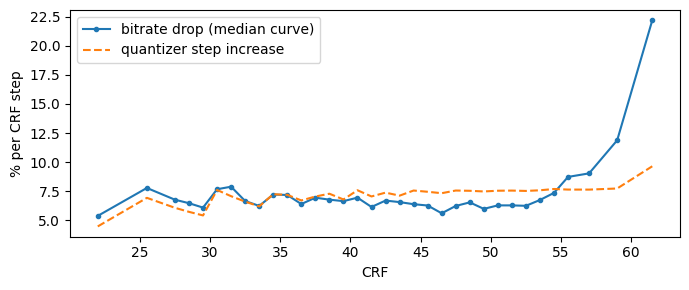

In [3]:
Q = np.array([87, 104, 128, 136, 144, 152, 164, 176, 188, 200, 215, 231, 247, 265, 285, 305, 329, 353,
              380, 408, 440, 474, 510, 550, 593, 639, 689, 743, 801, 864, 933, 1007, 1173, 1369, 1828], float)
ZQ = std(np.log(Q))
f = lambda x, a, b, A, w: a + b * (x + A * np.exp((x - 63) / w))
pA = curve_fit(f, CRF, Z, p0=[-3, 0.1, 8, 2], bounds=([-50, 0, 0, 0.3], [50, 1, 50, 20]), maxfev=50000)[0]
print(f'closed form: u = CRF + {pA[2]:.1f} exp((CRF - 63) / {pA[3]:.1f})')

mid = (CRF[1:] + CRF[:-1]) / 2
drop = -100 * np.median(np.diff(L73, axis=1), 0) / np.diff(CRF)
plt.figure(figsize=(7, 3))
plt.plot(mid, drop, marker='o', ms=3, label='bitrate drop (median curve)')
plt.plot(mid, 100 * np.diff(np.log(Q)) / np.diff(CRF), ls='--', label='quantizer step increase')
plt.xlabel('CRF'); plt.ylabel('% per CRF step'); plt.legend(); plt.tight_layout(); plt.show()

## Comparison with published models

Each model is fitted to each curve. `q` is the quantizer step, `q20` its value at CRF 20.

| model | form | parameters |
|---|---|---|
| Ma et al., IEEE TCSVT 2012 | `Vmax·exp(-c(q/q20 - 1))` | 2 |
| Q-STAR (Ou et al.) | `Vmax(1 - exp(-a(q20/q)^b)) / (1 - exp(-a))` | 3 |
| power law in CRF | `Vmax(1 - r·CRF^s)` | 3 |
| logistic in log q | `lo + (T - lo) / (1 + exp((log q - c)/s))` | 4 |
| this function, degree k | `min(100, 100·exp(-exp(p(u))))` on the quantizer axis or on the learned scale | k + 1 |

The published models were made for subjective scores on H.264 with 3-4 QPs.

In [4]:
qn = Q / Q[0]
cap = lambda v: np.minimum(100, v)

def fit_any(fn, y, starts):
    best = np.inf
    for s in starts:
        try:
            p = least_squares(lambda p: fn(p) - y, np.array(s, float), max_nfev=5000).x
            best = min(best, np.abs(fn(p) - y).mean())
        except Exception:
            pass
    return best

PUBLISHED = {
    'Ma et al. 2012': (2, lambda p: cap(p[0] * np.exp(-p[1] * (qn - 1))), [[v, c] for v in (100, 90) for c in (0.01, 0.05, 0.2)]),
    'Q-STAR': (3, lambda p: cap(p[0] * (1 - np.exp(-np.exp(p[1]) * qn ** (-np.exp(p[2])))) / (1 - np.exp(-np.exp(p[1])))),
               [[v, a, b] for v in (100, 95) for a in (0, 1, 2) for b in (-1, 0, 0.5)]),
    'power law in CRF': (3, lambda p: cap(p[0] * (1 - np.exp(p[1]) * (CRF / 40) ** p[2])), [[100, r, s] for r in (-3, -1) for s in (2, 4, 8)]),
    'logistic in log q': (4, lambda p: cap(p[1] + (p[0] - p[1]) / (1 + np.exp((ZQ - p[2]) / p[3]))), [[100, 0, c, .5] for c in (0, 1, 2)]),
}
SETS = {'v1, 73 sources': Y73, 'v1, 12 other': Y12, 'v0.6.1, 47 sources': Y47v0, 'v0.6.1, 12 other': Y12v0}
cache = OUT / 'curve_function_comparison.csv'
if cache.exists():
    H = pd.read_csv(cache)
else:
    rows = [dict(model=n, parameters=k, **{s: np.mean([fit_any(fn, y, st) for y in YY]) for s, YY in SETS.items()})
            for n, (k, fn, st) in PUBLISHED.items()]
    for axis, z in [('quantizer axis', ZQ), ('learned scale', Z)]:
        for deg in (1, 2, 3, 4):
            rows.append(dict(model=f'this function, {axis}, degree {deg}', parameters=deg + 1,
                             **{s: np.mean([fit(y, z, deg)[0] for y in YY]) for s, YY in SETS.items()}))
    H = pd.DataFrame(rows); H.to_csv(cache, index=False)
H.round(3)

,model,parameters,"v1, 73 sources","v1, 12 other","v0.6.1, 47 sources","v0.6.1, 12 other"
0,Ma et al. 2012,2,0.840,1.487,0.765,1.316
1,Q-STAR,3,1.119,1.371,0.989,0.976
2,power law in CRF,3,0.917,1.218,0.727,0.831
3,logistic in log q,4,0.689,0.917,0.519,0.562
4,"this function, quantizer axis, degree 1",2,0.943,1.402,0.943,1.315
5,"this function, quantizer axis, degree 2",3,0.836,1.136,0.739,0.871
6,"this function, quantizer axis, degree 3",4,0.243,0.306,0.205,0.257
7,"this function, quantizer axis, degree 4",5,0.133,0.190,0.103,0.120
8,"this function, learned scale, degree 1",2,0.617,1.133,1.015,1.864
9,"this function, learned scale, degree 2",3,0.279,0.552,0.292,0.589


- From 3 parameters on, this function has the lowest error in all four columns: 1.4 to 5.8 times lower than the best
  published model with the same number of parameters.
- With 2 parameters it is not better everywhere: Ma et al. is better under VMAF v0.6.1.
- With 5 parameters (degree 4) the error is 0.08-0.15.
- The learned scale is better than the quantizer axis under VMAF v1 at every degree; under v0.6.1 at degrees 2-3, and about
  equal at degree 4.
- Error roughly doubles on the 12 other sources, for all models.

## Presets

All presets of a source are fitted together: one curve shape, and preset `p` reads it at `(u - shift_p) / stretch_p`.
Presets 4-10, so that both sets can be compared. With the shared profile, shift and stretch are the medians of the
other sources (all 73 for the 12), and each source only scales them.

In [5]:
PS, REF = np.arange(4, 11), 4

def surface(Yv, D=None):
    n = len(Yv); c0 = fit(Yv[REF], Z, mono=False)[1]
    if D is None:      # own shift and stretch per preset
        fn = lambda p: np.stack([ginv(np.polyval(p[:5], (Z - s) / t))
                                 for s, t in zip(np.insert(p[5:5 + n - 1], REF, 0), np.insert(p[5 + n - 1:], REF, 1))])
        p0 = np.r_[c0, np.zeros(n - 1), np.ones(n - 1)]
    else:              # shared profile, 2 own strengths
        fn = lambda p: np.stack([ginv(np.polyval(p[:5], (Z - p[5] * s) / (1 + p[6] * (t - 1)))) for s, t in zip(*D)])
        p0 = np.r_[c0, 1, 1]
    p = least_squares(lambda p: (fn(p) - Yv).ravel(), p0, max_nfev=5000).x
    return np.abs(fn(p) - Yv).mean(1), p

V73 = {s: Y73[(S73 == s) & np.isin(P73, PS)] for s in dict.fromkeys(S73)}
V12 = {s: Y12[S12 == s] for s in dict.fromkeys(S12)}
grp = {s: G73[S73 == s][0] for s in V73}
own = {s: surface(v)[1] for s, v in V73.items()}
profile = lambda src: (np.insert(np.median([own[q][5:11] for q in src], 0), REF, 0), np.insert(np.median([own[q][11:] for q in src], 0), REF, 1))

sep = lambda V: np.mean([fit(y, Z)[0] for v in V.values() for y in v])
P = pd.DataFrame([
    dict(model='a separate curve per preset', numbers=35, **{'73 sources': sep(V73), '12 other': sep(V12)}),
    dict(model='one curve, own shift and stretch per preset', numbers=17,
         **{'73 sources': np.mean([surface(v)[0] for v in V73.values()]), '12 other': np.mean([surface(v)[0] for v in V12.values()])}),
    dict(model='one curve, shared profile', numbers=7,
         **{'73 sources': np.mean([surface(v, profile([q for q in V73 if grp[q] != grp[s]]))[0] for s, v in V73.items()]),
            '12 other': np.mean([surface(v, profile(list(V73)))[0] for v in V12.values()])})])
P.round(3)

,model,numbers,73 sources,12 other
0,a separate curve per preset,35,0.087,0.146
1,"one curve, own shift and stretch per preset",17,0.167,0.251
2,"one curve, shared profile",7,0.330,0.403


In [6]:
REF = 7      # all 10 presets of the 73 sources, preset 8 as reference
PS10 = np.arange(1, 11)
own10 = {s: surface(Y73[S73 == s])[1] for s in dict.fromkeys(S73)}
shift = np.insert(np.median([o[5:14] for o in own10.values()], 0), REF, 0)
stretch = np.insert(np.median([o[14:] for o in own10.values()], 0), REF, 1)
steps = 1 / np.gradient(Z, CRF)[list(CRF).index(40)]
prof = pd.DataFrame({'preset': PS10, 'shift vs preset 8 (CRF steps)': (shift * steps).round(1), 'stretch': stretch.round(3)})
prof.to_csv(ROOT / 'results' / 'curve_function_presets.csv', index=False)
prof.set_index('preset').T

preset,1,2,3,4,5,6,7,8,9,10
shift vs preset 8 (CRF steps),4.300,3.400,1.900,1.100,0.400,0.60,-0.100,0.0,-2.300,-3.90
stretch,1.052,1.045,1.088,1.091,1.091,1.02,1.008,1.0,0.949,0.97


A preset mostly moves the curve along CRF: at the same VMAF, preset 1 sits about 4 CRF steps higher than preset 8 and
preset 10 about 4 steps lower.

## Bitrate

`log(bitrate)` as a polynomial of the same scale, per curve, kept falling with CRF. Compared with the power law of Ma et al.
(`log R` linear in `log q`). Error in percent of bitrate.

In [7]:
def rate_err(L, x, deg):
    xf = np.interp(np.linspace(20, 63, 200), CRF, x); out = []
    for l in L:
        c = np.polyfit(x, l, deg)
        if deg > 1:
            c = least_squares(lambda p: np.r_[np.polyval(p, x) - l, 100 * np.maximum(0, np.polyval(np.polyder(p), xf))], c).x
        out.append(np.abs(np.exp(np.polyval(c, x) - l) - 1).mean() * 100)
    return np.mean(out)

R = pd.DataFrame([dict(model=n, parameters=k + 1, **{'73 sources': rate_err(L73, x, k), '12 other': rate_err(L12, x, k)})
                  for n, x, k in [('Ma et al. 2012: R = Rmax (q/q20)^-a', ZQ, 1), ('plain CRF, degree 4', std(CRF), 4),
                                  ('quantizer axis, degree 4', ZQ, 4), ('learned scale, degree 4', Z, 4)]])
R.round(2)

,model,parameters,73 sources,12 other
0,Ma et al. 2012: R = Rmax (q/q20)^-a,2,7.66,11.22
1,"plain CRF, degree 4",5,2.36,4.06
2,"quantizer axis, degree 4",5,1.54,2.93
3,"learned scale, degree 4",5,0.82,2.91


## Why the scale bends (SVT-AV1 v4.0.1 source)

- Mode decision multiplies lambda by `lambda_weight / 128` (`md_process.c`). `lambda_weight` is 150 for frame QP >= 16,
  175 for QP >= 56 and 300 for non-key frames with QP >= 62 (`enc_mode_config.c`). This holds for all presets except the
  research mode (preset -1). Lambda therefore goes up about 17% at QP 56 and doubles at QP 62.
- QP banding (`seq_qp_mod = 2` by default, `enc_handle.c`) lowers warped motion, non-square partition search, OBMC and
  transform-size search above CRF 55-60.

The measured bitrate drop per CRF step changes at the same places:

In [8]:
pd.DataFrame({'CRF step': [f'{int(a)}-{int(b)}' for a, b in zip(CRF[:-1], CRF[1:])], 'bitrate drop %': drop.round(1)}).iloc[-8:].set_index('CRF step').T

CRF step,51-52,52-53,53-54,54-55,55-56,56-58,58-60,60-63
bitrate drop %,6.3,6.2,6.7,7.3,8.7,9.0,11.9,22.2


This is read from the code; a confirmation would need encodes with these rules switched off.

In [9]:
H.round(4).to_csv(ROOT / 'results' / 'curve_function_comparison.csv', index=False)
P.round(4).to_csv(ROOT / 'results' / 'curve_function_preset_models.csv', index=False)
R.round(3).to_csv(ROOT / 'results' / 'curve_function_bitrate.csv', index=False)